# **1. Loading the Data**

In [60]:
# I am importing the pandas library for data manipulation and analysis.
import pandas as pd

# I am importing the files module to upload the dataset from my local system.
from google.colab import files

# I am uploading the dataset file from my computer.
uploaded = files.upload()

# I am reading the uploaded CSV file into a pandas DataFrame.
df = pd.read_csv("Banglore_traffic_Dataset.csv")

# I am displaying the first five rows of the dataset to verify that it has been loaded successfully.
df.head()

Saving Banglore_traffic_Dataset.csv to Banglore_traffic_Dataset (7).csv


,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,01-01-2022,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,01-01-2022,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,01-01-2022,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,01-01-2022,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,01-01-2022,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No


# **2. Running the basic inspection**

In [61]:
# I am checking the number of rows and columns in the dataset.
print("Shape of the dataset:", df.shape)

Shape of the dataset: (8936, 16)


In [62]:
# I am displaying the names of all the columns in the dataset.
print("\nColumn Names:")
print(df.columns)


Column Names:
Index(['Date', 'Area Name', 'Road/Intersection Name', 'Traffic Volume',
       'Average Speed', 'Travel Time Index', 'Congestion Level',
       'Road Capacity Utilization', 'Incident Reports', 'Environmental Impact',
       'Public Transport Usage', 'Traffic Signal Compliance', 'Parking Usage',
       'Pedestrian and Cyclist Count', 'Weather Conditions',
       'Roadwork and Construction Activity'],
      dtype='object')


In [63]:
# I am displaying information about the dataset, including data types and non-null values.
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8936 entries, 0 to 8935
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                8936 non-null   object 
 1   Area Name                           8936 non-null   object 
 2   Road/Intersection Name              8936 non-null   object 
 3   Traffic Volume                      8936 non-null   int64  
 4   Average Speed                       8936 non-null   float64
 5   Travel Time Index                   8936 non-null   float64
 6   Congestion Level                    8936 non-null   float64
 7   Road Capacity Utilization           8936 non-null   float64
 8   Incident Reports                    8936 non-null   int64  
 9   Environmental Impact                8936 non-null   float64
 10  Public Transport Usage              8936 non-null   float64
 11  Traffic Signal Compli

In [64]:
# I am generating descriptive statistics for the numerical columns.
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
       Traffic Volume  Average Speed  Travel Time Index  Congestion Level  \
count     8936.000000    8936.000000        8936.000000       8936.000000   
mean     29236.048120      39.447427           1.375554         80.818041   
std      13001.808801      10.707244           0.165319         23.533182   
min       4233.000000      20.000000           1.000039          5.160279   
25%      19413.000000      31.775825           1.242459         64.292905   
50%      27600.000000      39.199368           1.500000         92.389018   
75%      38058.500000      46.644517           1.500000        100.000000   
max      72039.000000      89.790843           1.500000        100.000000   

       Road Capacity Utilization  Incident Reports  Environmental Impact  \
count                8936.000000       8936.000000           8936.000000   
mean                   92.029215          1.570389            108.472096   
std                    16.583341          1.420047   

In [65]:
# I am displaying the data type of each column in the dataset.
print("\nData Types:")
print(df.dtypes)


Data Types:
Date                                   object
Area Name                              object
Road/Intersection Name                 object
Traffic Volume                          int64
Average Speed                         float64
Travel Time Index                     float64
Congestion Level                      float64
Road Capacity Utilization             float64
Incident Reports                        int64
Environmental Impact                  float64
Public Transport Usage                float64
Traffic Signal Compliance             float64
Parking Usage                         float64
Pedestrian and Cyclist Count            int64
Weather Conditions                     object
Roadwork and Construction Activity     object
dtype: object


In [66]:
# I am checking for missing values in each column.
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Date                                  0
Area Name                             0
Road/Intersection Name                0
Traffic Volume                        0
Average Speed                         0
Travel Time Index                     0
Congestion Level                      0
Road Capacity Utilization             0
Incident Reports                      0
Environmental Impact                  0
Public Transport Usage                0
Traffic Signal Compliance             0
Parking Usage                         0
Pedestrian and Cyclist Count          0
Weather Conditions                    0
Roadwork and Construction Activity    0
dtype: int64


In [67]:
# I am checking for duplicate rows in the dataset.
print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())


Number of Duplicate Rows:
0


In [68]:
# I am identifying the categorical columns in the dataset.
categorical_columns = df.select_dtypes(include='object').columns

In [69]:
# I am counting the number of unique values in each categorical column.
print("\nNumber of Unique Values in Categorical Columns:")
for column in categorical_columns:
    print(f"{column}: {df[column].nunique()}")


Number of Unique Values in Categorical Columns:
Date: 952
Area Name: 8
Road/Intersection Name: 16
Weather Conditions: 5
Roadwork and Construction Activity: 2


# **3. Data Cleaning**

There are no missing values, no null values and no duplicate rows so there isn't much data cleaning to do. Therefore we are only converting the Date column to datetime. This is because it enables time-based analysis which we may do later.

In [70]:
# I am converting the 'Date' column to datetime format using the DD-MM-YYYY format.
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# I am verifying that the 'Date' column has been converted successfully.
print(df['Date'].dtype)

datetime64[ns]


# **4. Feature Engineering**

In [71]:
# I am extracting the year from the 'Date' column.
df['Year'] = df['Date'].dt.year

# I am extracting the month name from the 'Date' column.
df['Month'] = df['Date'].dt.month_name()

# I am extracting the day name from the 'Date' column.
df['Day'] = df['Date'].dt.day_name()

# I am identifying whether each date falls on a weekend.
df['Weekend'] = df['Day'].isin(['Saturday', 'Sunday'])

# I am displaying the first five rows to verify the newly created features.
df.head()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity,Year,Month,Day,Weekend
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No,2022,January,Saturday,True
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No,2022,January,Saturday,True
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No,2022,January,Saturday,True
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No,2022,January,Saturday,True
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No,2022,January,Saturday,True


# **5. Exploratory Data Analysis (EDA)**

In [72]:
# I am displaying the first five rows of the dataset.
df.head()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity,Year,Month,Day,Weekend
0,2022-01-01,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No,2022,January,Saturday,True
1,2022-01-01,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No,2022,January,Saturday,True
2,2022-01-01,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No,2022,January,Saturday,True
3,2022-01-01,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No,2022,January,Saturday,True
4,2022-01-01,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No,2022,January,Saturday,True


In [73]:
# I am displaying the last five rows of the dataset.
df.tail()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity,Year,Month,Day,Weekend
8931,2024-08-09,Electronic City,Hosur Road,11387,23.440276,1.262384,35.871483,57.354487,1,72.774,21.523289,83.530352,97.898279,211,Fog,No,2024,August,Friday,False
8932,2024-08-09,M.G. Road,Trinity Circle,36477,45.168429,1.500000,100.000000,100.000000,3,122.954,29.822312,60.738488,60.355967,95,Clear,No,2024,August,Friday,False
8933,2024-08-09,M.G. Road,Anil Kumble Circle,42822,22.028609,1.500000,100.000000,100.000000,1,135.644,43.185905,85.321627,61.333731,110,Clear,No,2024,August,Friday,False
8934,2024-08-09,Jayanagar,South End Circle,20540,52.254798,1.020520,72.639152,97.845527,2,91.080,44.416043,89.586947,79.197198,94,Clear,No,2024,August,Friday,False
8935,2024-08-09,Yeshwanthpur,Yeshwanthpur Circle,14705,31.128967,1.048720,43.409821,77.734621,1,79.410,26.616725,80.778753,60.602672,201,Rain,No,2024,August,Friday,False


# A. Analyzing the distribution of numerical variables

In [74]:
# I am identifying all the numerical columns in the dataset.
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

# I am displaying the names of the numerical columns.
print("Numerical Columns:")
print(numerical_columns)

Numerical Columns:
Index(['Traffic Volume', 'Average Speed', 'Travel Time Index',
       'Congestion Level', 'Road Capacity Utilization', 'Incident Reports',
       'Environmental Impact', 'Public Transport Usage',
       'Traffic Signal Compliance', 'Parking Usage',
       'Pedestrian and Cyclist Count'],
      dtype='object')


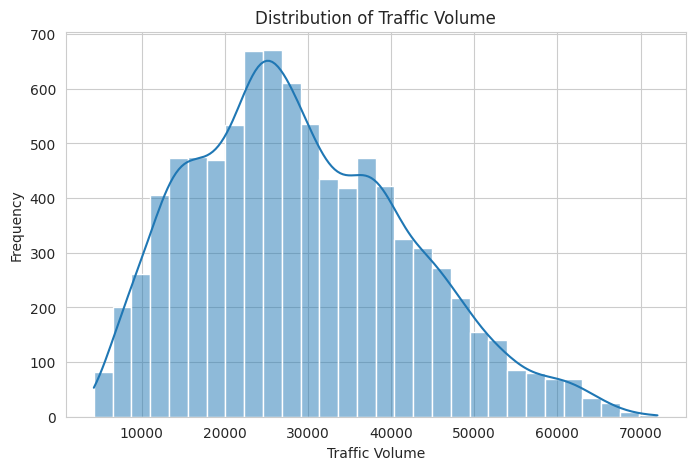

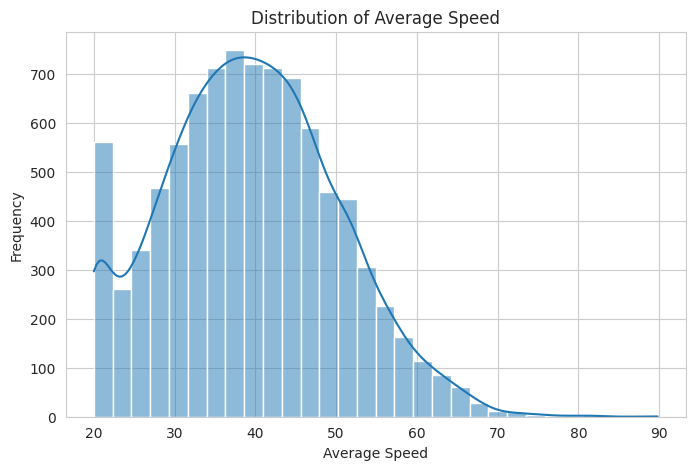

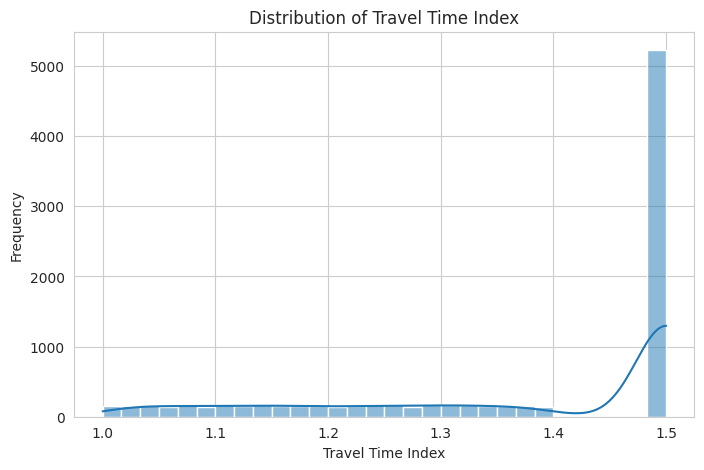

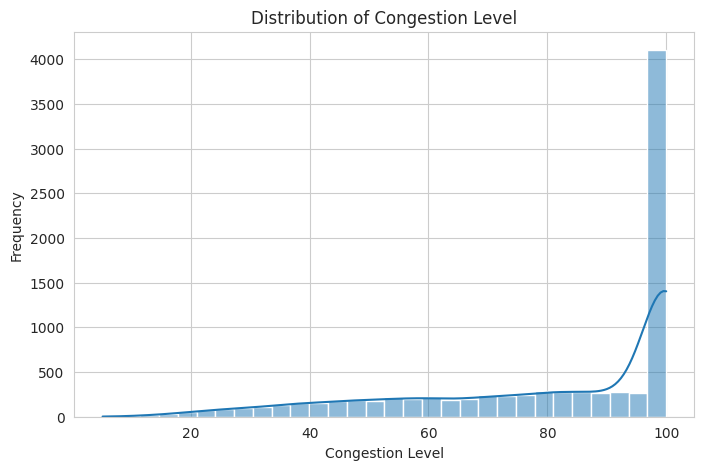

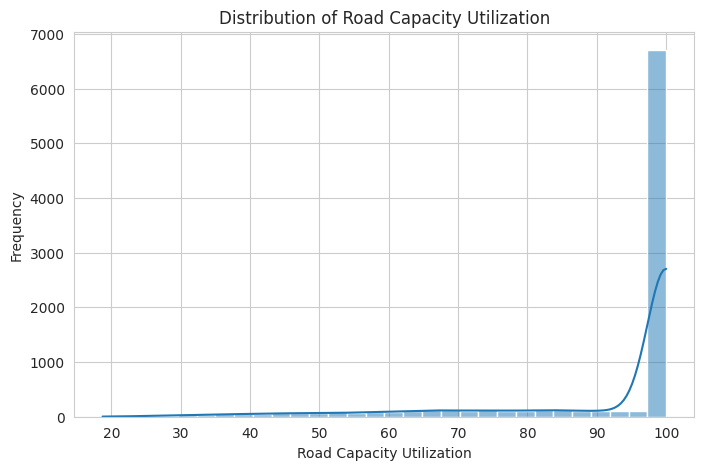

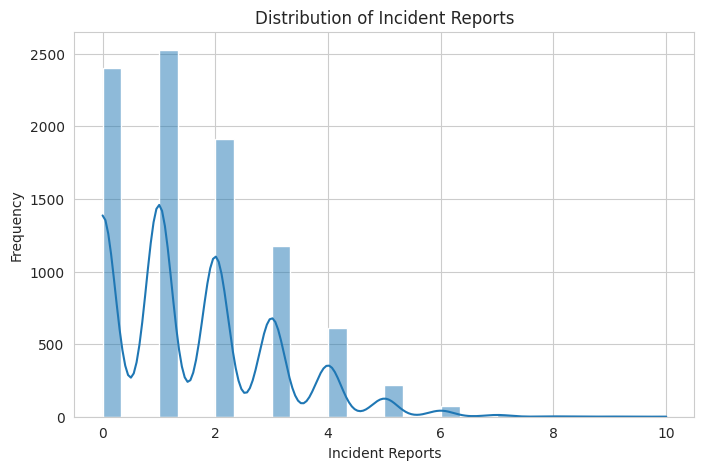

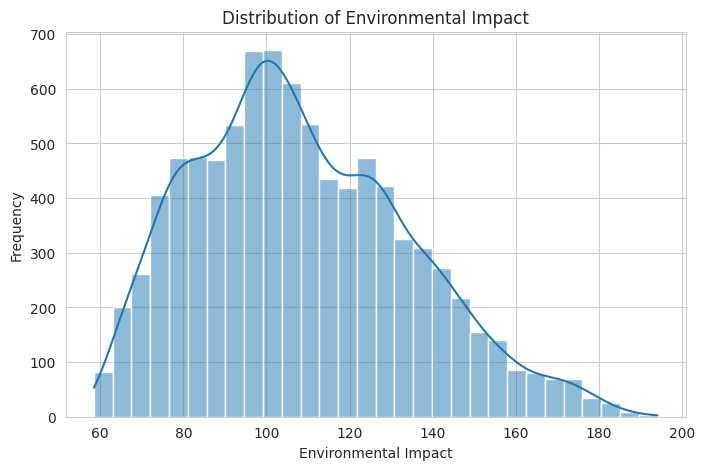

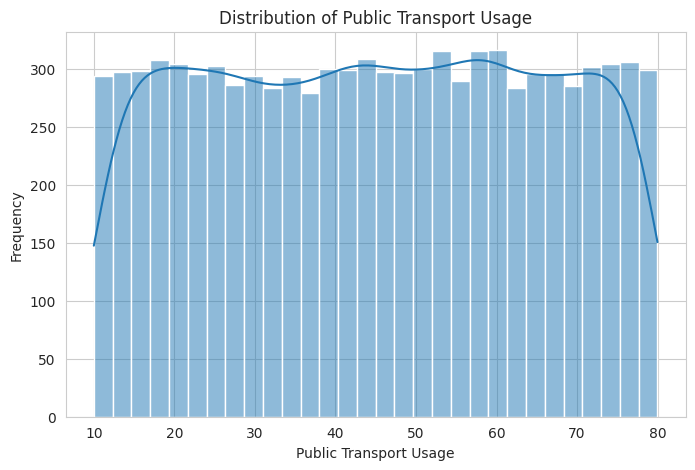

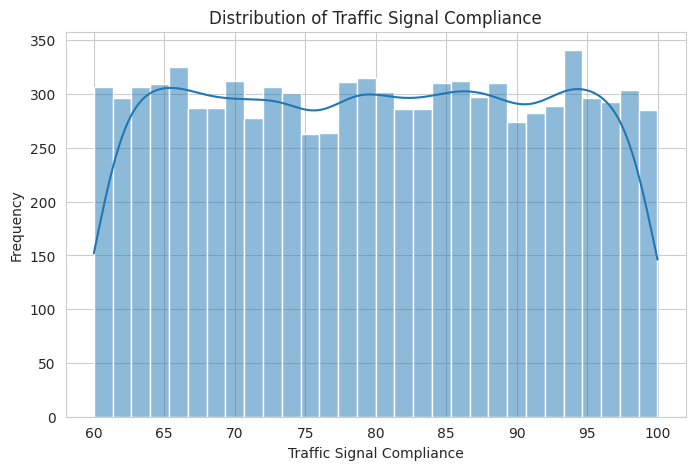

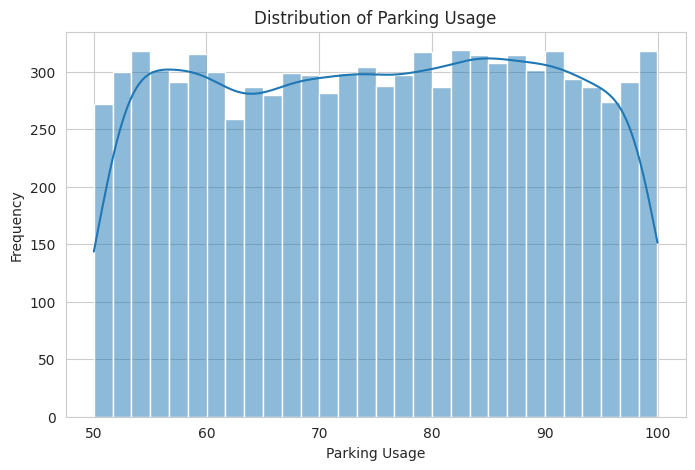

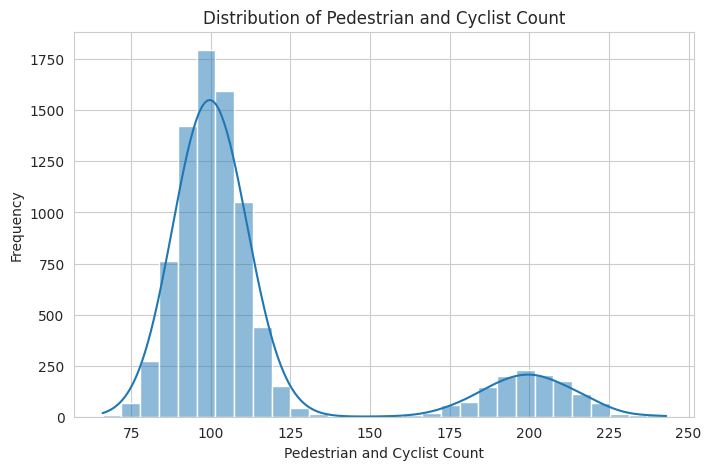

In [75]:
# I am importing the required libraries for data visualization.
import matplotlib.pyplot as plt
import seaborn as sns

# I am setting the visual style for the plots.
sns.set_style("whitegrid")

# I am creating histograms for all numerical variables to understand their distributions.
for column in numerical_columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df[column], bins=30, kde=True)

    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

    plt.show()

In [76]:
# I am generating summary statistics for the numerical variables.
df[numerical_columns].describe()

,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count
count,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000
mean,29236.048120,39.447427,1.375554,80.818041,92.029215,1.570389,108.472096,45.086651,79.950243,75.155597,114.533348
std,13001.808801,10.707244,0.165319,23.533182,16.583341,1.420047,26.003618,20.208460,11.585006,14.409394,36.812573
min,4233.000000,20.000000,1.000039,5.160279,18.739771,0.000000,58.466000,10.006853,60.003933,50.020411,66.000000
25%,19413.000000,31.775825,1.242459,64.292905,97.354990,0.000000,88.826000,27.341191,69.828270,62.545895,94.000000
50%,27600.000000,39.199368,1.500000,92.389018,100.000000,1.000000,105.200000,45.170684,79.992773,75.317610,102.000000
75%,38058.500000,46.644517,1.500000,100.000000,100.000000,2.000000,126.117000,62.426485,89.957358,87.518589,111.000000
max,72039.000000,89.790843,1.500000,100.000000,100.000000,10.000000,194.078000,79.979744,99.993652,99.995049,243.000000


# B. Distribution of Categorical Variables

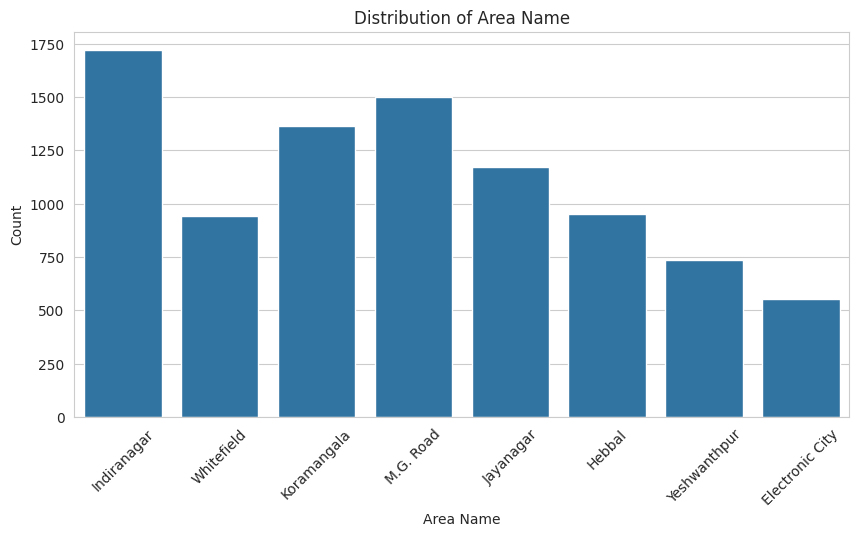

In [77]:
# I am creating a count plot to visualize the distribution of observations across different areas.
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='Area Name')

plt.title('Distribution of Area Name')
plt.xlabel('Area Name')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

In [78]:
# I am displaying the frequency of observations for each area.
print(df['Area Name'].value_counts())

Area Name
Indiranagar        1720
M.G. Road          1501
Koramangala        1364
Jayanagar          1173
Hebbal              950
Whitefield          942
Yeshwanthpur        734
Electronic City     552
Name: count, dtype: int64


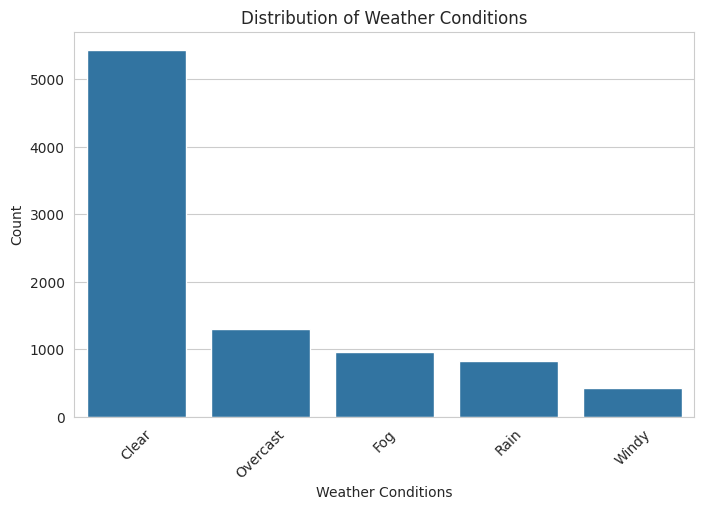

In [79]:
# I am creating a count plot to visualize the distribution of different weather conditions.
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='Weather Conditions')

plt.title('Distribution of Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Count')
plt.xticks(rotation=45)

plt.show()

In [80]:
# I am displaying the frequency of each weather condition.
print(df['Weather Conditions'].value_counts())

Weather Conditions
Clear       5426
Overcast    1296
Fog          959
Rain         827
Windy        428
Name: count, dtype: int64


# C. Area-wise Analysis

Questions:

Which area has the highest traffic?

Which area has the highest congestion?

Which area has the highest average speed?

Visualizations: Bar plots

Area Name
Koramangala        40832.253666
M.G. Road          35300.426382
Indiranagar        32284.388372
Hebbal             26533.232632
Jayanagar          24601.329923
Whitefield         21295.127389
Yeshwanthpur       18931.546322
Electronic City    16346.644928
Name: Traffic Volume, dtype: float64


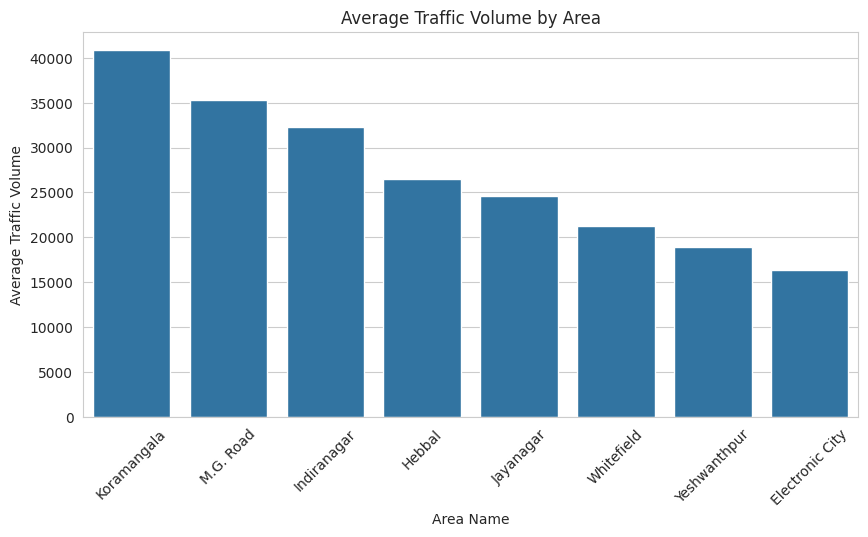

In [81]:
# I am calculating the average traffic volume for each area.
area_traffic = df.groupby('Area Name')['Traffic Volume'].mean().sort_values(ascending=False)

# I am displaying the average traffic volume for each area.
print(area_traffic)

# I am creating a bar plot to compare the average traffic volume across different areas.
plt.figure(figsize=(10, 5))
sns.barplot(x=area_traffic.index, y=area_traffic.values)

plt.title('Average Traffic Volume by Area')
plt.xlabel('Area Name')
plt.ylabel('Average Traffic Volume')
plt.xticks(rotation=45)

plt.show()

Area Name
Koramangala        93.985536
M.G. Road          90.579670
Indiranagar        87.641890
Hebbal             80.087244
Jayanagar          76.998324
Whitefield         69.054661
Yeshwanthpur       62.369634
Electronic City    54.454507
Name: Congestion Level, dtype: float64


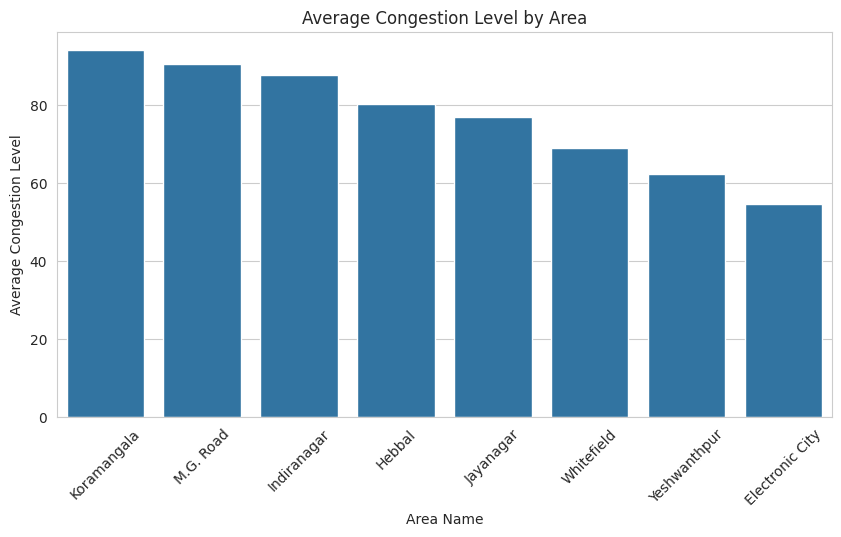

In [82]:
# I am calculating the average congestion level for each area.
area_congestion = df.groupby('Area Name')['Congestion Level'].mean().sort_values(ascending=False)

# I am displaying the average congestion level for each area.
print(area_congestion)

# I am creating a bar plot to compare the average congestion level across different areas.
plt.figure(figsize=(10, 5))
sns.barplot(x=area_congestion.index, y=area_congestion.values)

plt.title('Average Congestion Level by Area')
plt.xlabel('Area Name')
plt.ylabel('Average Congestion Level')
plt.xticks(rotation=45)

plt.show()

Area Name
Electronic City    43.661789
Yeshwanthpur       43.447576
Whitefield         42.140866
Hebbal             40.149855
Jayanagar          39.789692
Indiranagar        38.644341
M.G. Road          37.535189
Koramangala        36.062629
Name: Average Speed, dtype: float64


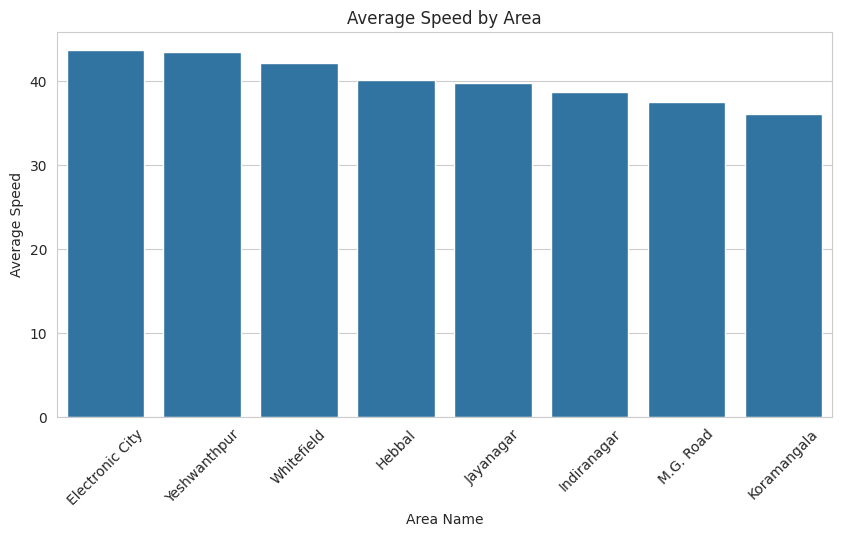

In [83]:
# I am calculating the average speed for each area.
area_speed = df.groupby('Area Name')['Average Speed'].mean().sort_values(ascending=False)

# I am displaying the average speed for each area.
print(area_speed)

# I am creating a bar plot to compare the average speed across different areas.
plt.figure(figsize=(10, 5))
sns.barplot(x=area_speed.index, y=area_speed.values)

plt.title('Average Speed by Area')
plt.xlabel('Area Name')
plt.ylabel('Average Speed')
plt.xticks(rotation=45)

plt.show()

# D. Road-wise Analysis

Questions:

Which roads experience the most traffic?

Which roads are the most congested?

Visualizations: Horizontal bar plots

Road/Intersection Name
Sony World Junction    41470.801170
Sarjapur Road          40189.950000
Trinity Circle         35350.137466
Anil Kumble Circle     35251.828722
CMH Road               32611.924419
100 Feet Road          31956.852326
Hebbal Flyover         26794.924051
Ballari Road           26272.640756
South End Circle       24704.119730
Jayanagar 4th Block    24496.236207
ITPL Main Road         21866.037778
Marathahalli Bridge    20772.953252
Yeshwanthpur Circle    19277.115282
Tumkur Road            18574.490305
Hosur Road             16557.223827
Silk Board Junction    16134.534545
Name: Traffic Volume, dtype: float64


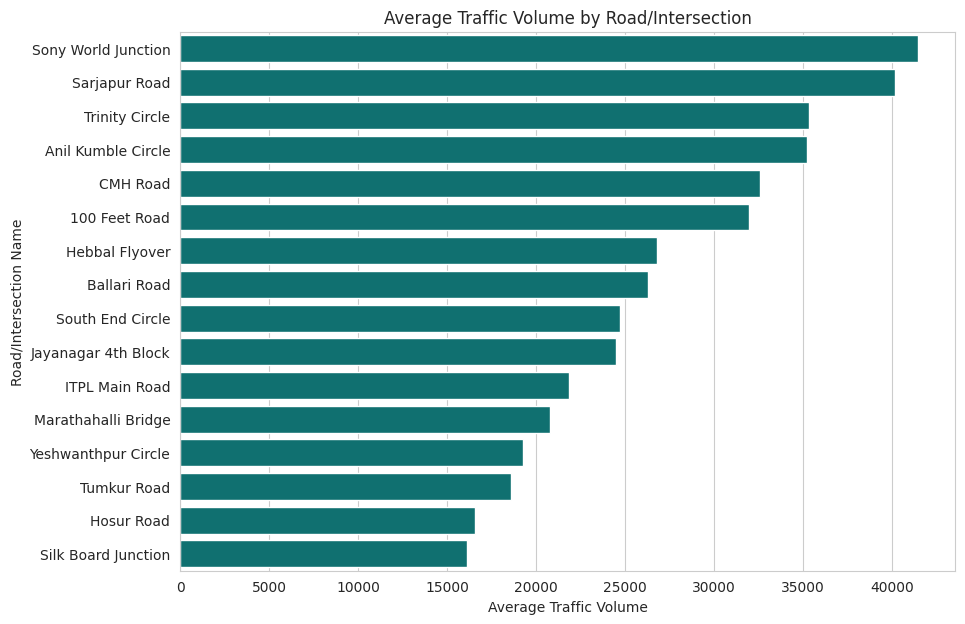

In [84]:
# I am calculating the average traffic volume for each road/intersection.
road_traffic = df.groupby('Road/Intersection Name')['Traffic Volume'].mean().sort_values(ascending=False)

# I am displaying the average traffic volume for each road/intersection.
print(road_traffic)

# I am creating a horizontal bar plot to compare the average traffic volume across different roads/intersections.
plt.figure(figsize=(10, 7))
sns.barplot(x=road_traffic.values, y=road_traffic.index, color='teal')

plt.title('Average Traffic Volume by Road/Intersection')
plt.xlabel('Average Traffic Volume')
plt.ylabel('Road/Intersection Name')

plt.show()

Road/Intersection Name
Sony World Junction    94.125087
Sarjapur Road          93.845163
Anil Kumble Circle     90.782145
Trinity Circle         90.372556
CMH Road               88.176365
100 Feet Road          87.107415
Hebbal Flyover         80.662354
Ballari Road           79.514551
South End Circle       77.277398
Jayanagar 4th Block    76.712995
ITPL Main Road         71.101106
Marathahalli Bridge    67.182913
Yeshwanthpur Circle    63.744162
Tumkur Road            60.949415
Hosur Road             55.203745
Silk Board Junction    53.699820
Name: Congestion Level, dtype: float64


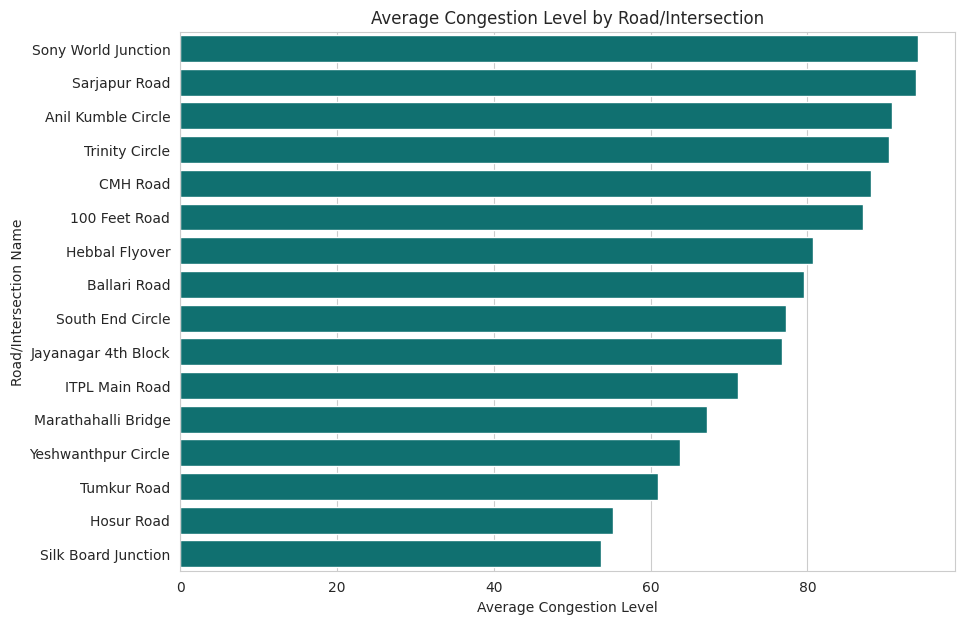

In [85]:
# I am calculating the average congestion level for each road/intersection.
road_congestion = df.groupby('Road/Intersection Name')['Congestion Level'].mean().sort_values(ascending=False)

# I am displaying the average congestion level for each road/intersection.
print(road_congestion)

# I am creating a horizontal bar plot to compare the average congestion level across different roads/intersections.
plt.figure(figsize=(10, 7))
sns.barplot(x=road_congestion.values, y=road_congestion.index, color='teal')

plt.title('Average Congestion Level by Road/Intersection')
plt.xlabel('Average Congestion Level')
plt.ylabel('Road/Intersection Name')

plt.show()

# E. Weather Analysis

Questions:

Does weather affect traffic volume?

Does weather affect congestion?

Does weather affect average speed?

Visualizations:

Box plots and Bar plots

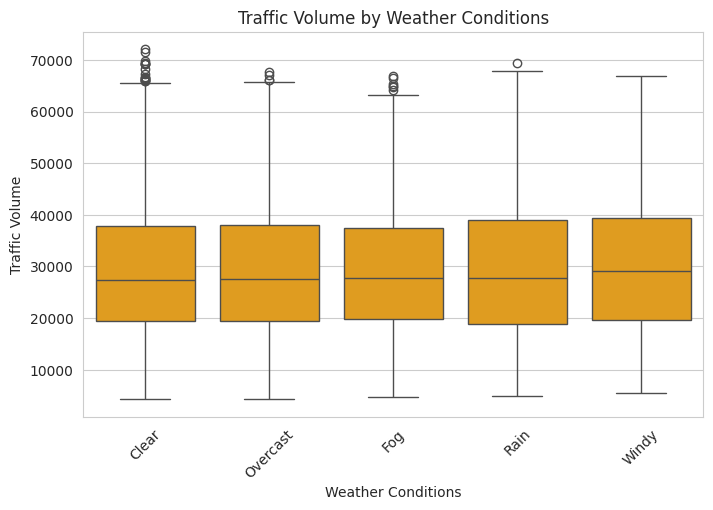

In [86]:
# I am creating a box plot to examine how traffic volume varies under different weather conditions.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Weather Conditions', y='Traffic Volume', color='orange')

plt.title('Traffic Volume by Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Traffic Volume')
plt.xticks(rotation=45)

plt.show()

Weather Conditions
Windy       30163.217290
Rain        29558.703748
Fog         29183.318040
Clear       29166.666790
Overcast    29053.460648
Name: Traffic Volume, dtype: float64


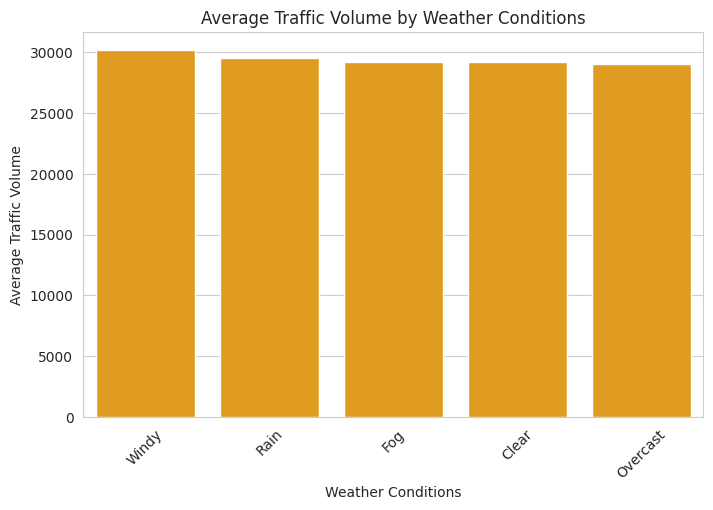

In [87]:
# I am calculating the average traffic volume for each weather condition.
weather_traffic = df.groupby('Weather Conditions')['Traffic Volume'].mean().sort_values(ascending=False)

# I am displaying the average traffic volume for each weather condition.
print(weather_traffic)

# I am creating a bar plot to compare the average traffic volume across different weather conditions.
plt.figure(figsize=(8, 5))
sns.barplot(x=weather_traffic.index, y=weather_traffic.values, color='orange')

plt.title('Average Traffic Volume by Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Average Traffic Volume')
plt.xticks(rotation=45)

plt.show()

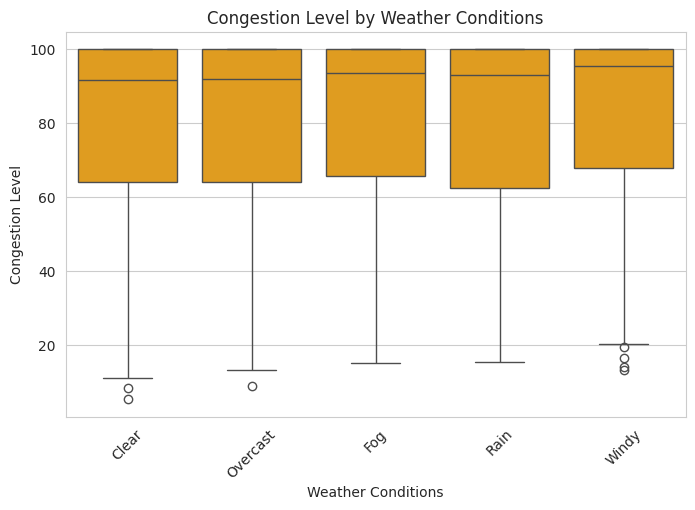

In [88]:
# I am creating a box plot to examine how congestion level varies under different weather conditions.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Weather Conditions', y='Congestion Level', color='orange')

plt.title('Congestion Level by Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Congestion Level')
plt.xticks(rotation=45)

plt.show()

Weather Conditions
Windy       82.369907
Fog         81.609357
Clear       80.723064
Rain        80.537699
Overcast    80.296523
Name: Congestion Level, dtype: float64


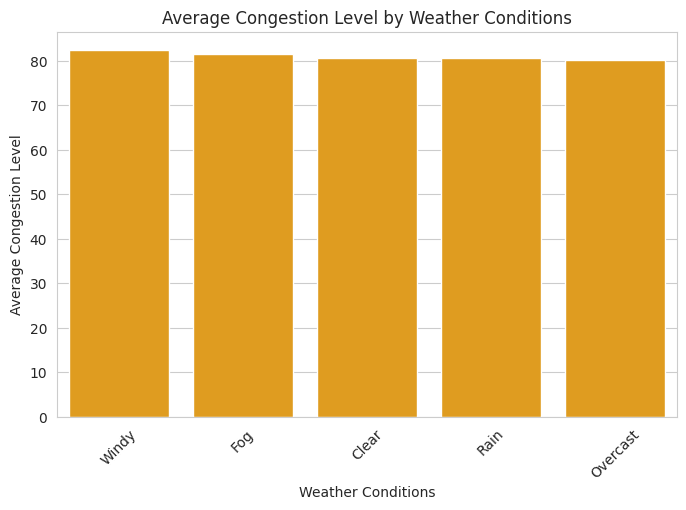

In [89]:
# I am calculating the average congestion level for each weather condition.
weather_congestion = df.groupby('Weather Conditions')['Congestion Level'].mean().sort_values(ascending=False)

# I am displaying the average congestion level for each weather condition.
print(weather_congestion)

# I am creating a bar plot to compare the average congestion level across different weather conditions.
plt.figure(figsize=(8, 5))
sns.barplot(x=weather_congestion.index, y=weather_congestion.values, color='orange')

plt.title('Average Congestion Level by Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Average Congestion Level')
plt.xticks(rotation=45)

plt.show()

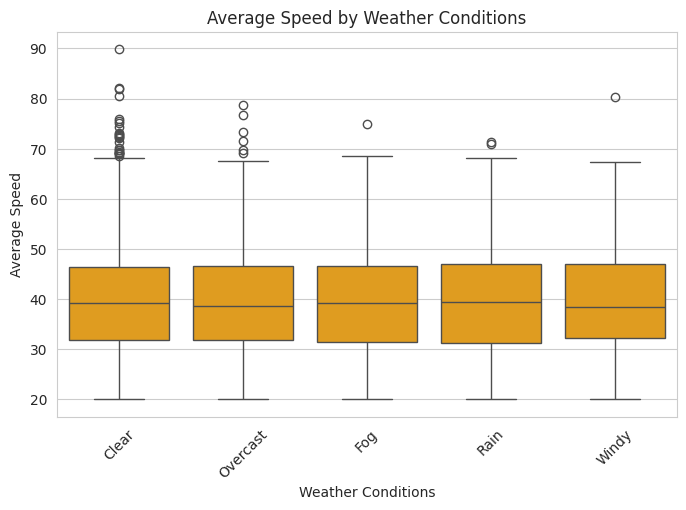

In [90]:
# I am creating a box plot to examine how average speed varies under different weather conditions.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='Weather Conditions', y='Average Speed', color='orange')

plt.title('Average Speed by Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Average Speed')
plt.xticks(rotation=45)

plt.show()

Weather Conditions
Windy       39.523641
Fog         39.472225
Clear       39.466786
Overcast    39.428241
Rain        39.282280
Name: Average Speed, dtype: float64


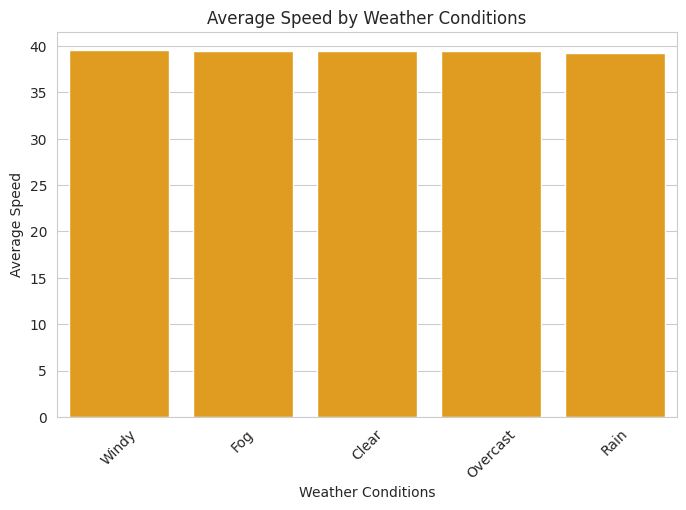

In [91]:
# I am calculating the average speed for each weather condition.
weather_speed = df.groupby('Weather Conditions')['Average Speed'].mean().sort_values(ascending=False)

# I am displaying the average speed for each weather condition.
print(weather_speed)

# I am creating a bar plot to compare the average speed across different weather conditions.
plt.figure(figsize=(8, 5))
sns.barplot(x=weather_speed.index, y=weather_speed.values, color='orange')

plt.title('Average Speed by Weather Conditions')
plt.xlabel('Weather Conditions')
plt.ylabel('Average Speed')
plt.xticks(rotation=45)

plt.show()

# F. Construction Activity Analysis

Comparing: Construction = Yes v/s Construction = No

Metrics: Traffic Volume, Congestion, Average Speed

Visualizations: Box plot and Bar plot

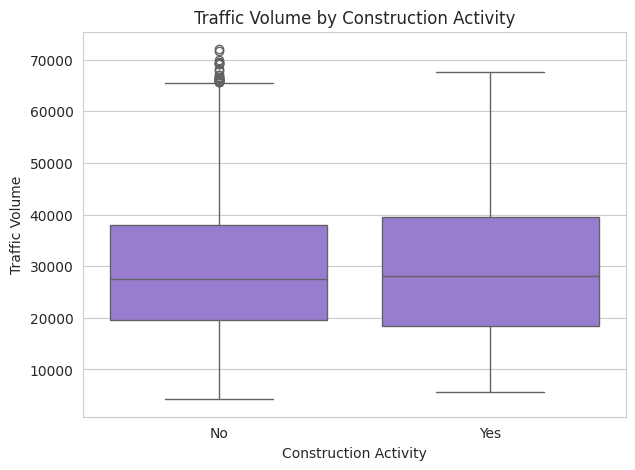

In [92]:
# I am creating a box plot to examine how traffic volume varies based on construction activity.
plt.figure(figsize=(7, 5))
sns.boxplot(
    data=df,
    x='Roadwork and Construction Activity',
    y='Traffic Volume',
    color='mediumpurple'
)

plt.title('Traffic Volume by Construction Activity')
plt.xlabel('Construction Activity')
plt.ylabel('Traffic Volume')

plt.show()

Roadwork and Construction Activity
No     29194.610504
Yes    29614.436508
Name: Traffic Volume, dtype: float64


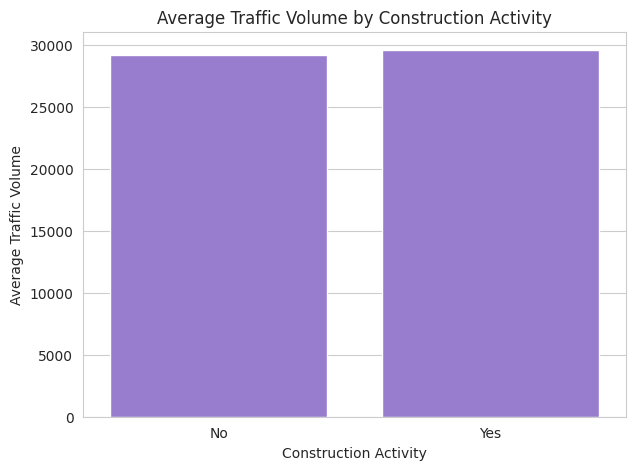

In [93]:
# I am calculating the average traffic volume based on construction activity.
construction_traffic = df.groupby('Roadwork and Construction Activity')['Traffic Volume'].mean()

# I am displaying the average traffic volume for each construction activity category.
print(construction_traffic)

# I am creating a bar plot to compare the average traffic volume based on construction activity.
plt.figure(figsize=(7,5))
sns.barplot(
    x=construction_traffic.index,
    y=construction_traffic.values,
    color='mediumpurple'
)

plt.title('Average Traffic Volume by Construction Activity')
plt.xlabel('Construction Activity')
plt.ylabel('Average Traffic Volume')

plt.show()

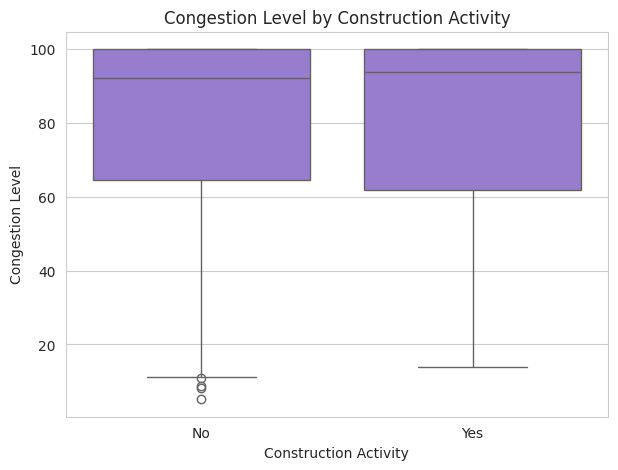

In [94]:
# I am creating a box plot to examine how congestion level varies based on construction activity.
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x='Roadwork and Construction Activity',
    y='Congestion Level',
    color='mediumpurple'
)

plt.title('Congestion Level by Construction Activity')
plt.xlabel('Construction Activity')
plt.ylabel('Congestion Level')

plt.show()

Roadwork and Construction Activity
No     80.822195
Yes    80.780110
Name: Congestion Level, dtype: float64


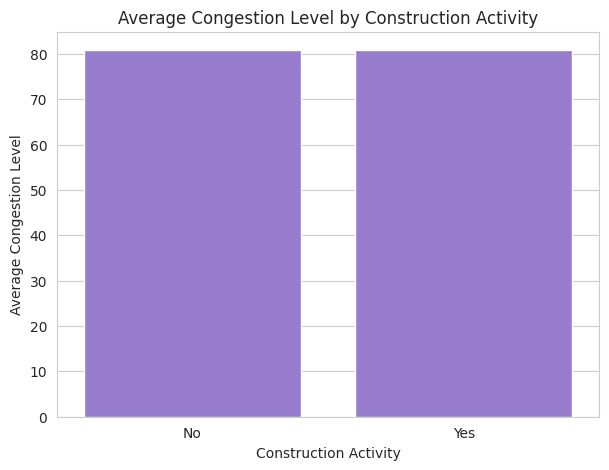

In [95]:
# I am calculating the average congestion level based on construction activity.
construction_congestion = df.groupby('Roadwork and Construction Activity')['Congestion Level'].mean()

# I am displaying the average congestion level for each construction activity category.
print(construction_congestion)

# I am creating a bar plot to compare the average congestion level based on construction activity.
plt.figure(figsize=(7,5))
sns.barplot(
    x=construction_congestion.index,
    y=construction_congestion.values,
    color='mediumpurple'
)

plt.title('Average Congestion Level by Construction Activity')
plt.xlabel('Construction Activity')
plt.ylabel('Average Congestion Level')

plt.show()

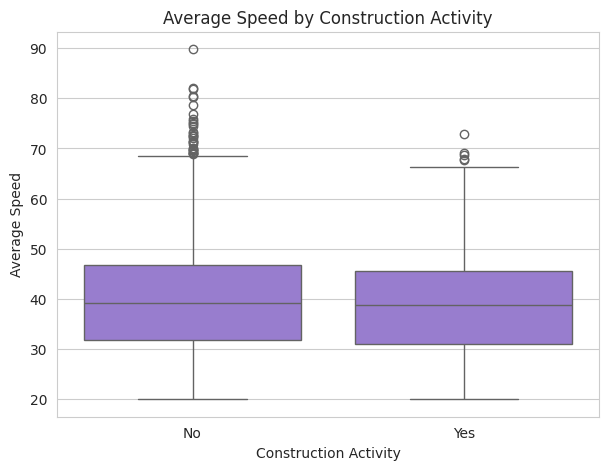

In [96]:
# I am creating a box plot to examine how average speed varies based on construction activity.
plt.figure(figsize=(7,5))
sns.boxplot(
    data=df,
    x='Roadwork and Construction Activity',
    y='Average Speed',
    color='mediumpurple'
)

plt.title('Average Speed by Construction Activity')
plt.xlabel('Construction Activity')
plt.ylabel('Average Speed')

plt.show()

Roadwork and Construction Activity
No     39.499814
Yes    38.969050
Name: Average Speed, dtype: float64


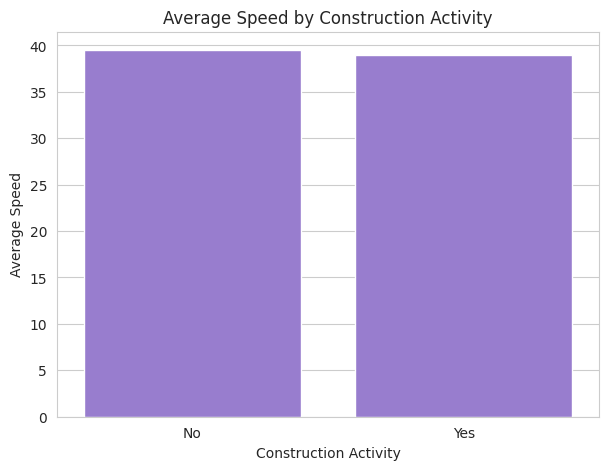

In [97]:
# I am calculating the average speed based on construction activity.
construction_speed = df.groupby('Roadwork and Construction Activity')['Average Speed'].mean()

# I am displaying the average speed for each construction activity category.
print(construction_speed)

# I am creating a bar plot to compare the average speed based on construction activity.
plt.figure(figsize=(7,5))
sns.barplot(
    x=construction_speed.index,
    y=construction_speed.values,
    color='mediumpurple'
)

plt.title('Average Speed by Construction Activity')
plt.xlabel('Construction Activity')
plt.ylabel('Average Speed')

plt.show()

# G. Correlation Analysis

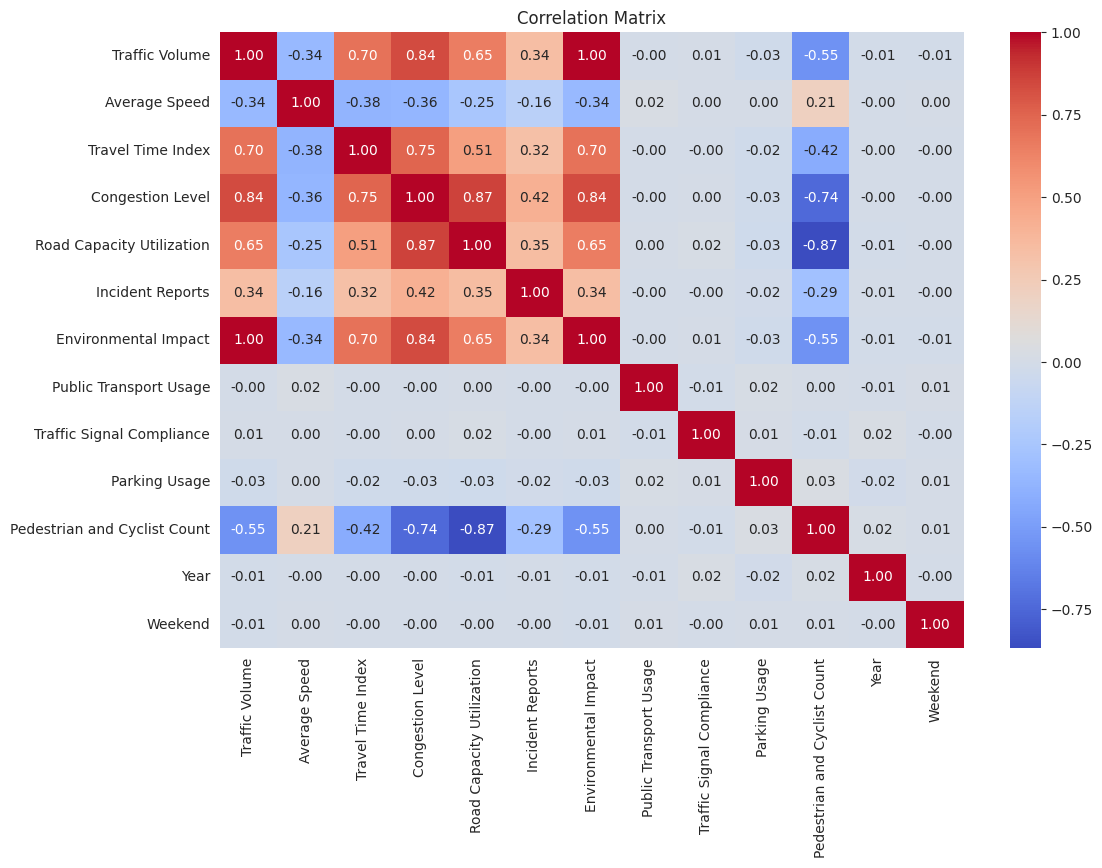

In [98]:
# I am calculating the correlation matrix for the numerical columns.
correlation_matrix = df.corr(numeric_only=True)

# I am creating a heatmap to visualize the correlation between numerical variables.
plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

# H. Relationship Analysis

Using scatter plots for -

Traffic Volume vs Average Speed

Traffic Volume vs Congestion Level

Traffic Volume vs Environmental Impact

Traffic Volume vs Public Transport Usage

Average Speed vs Travel Time Index

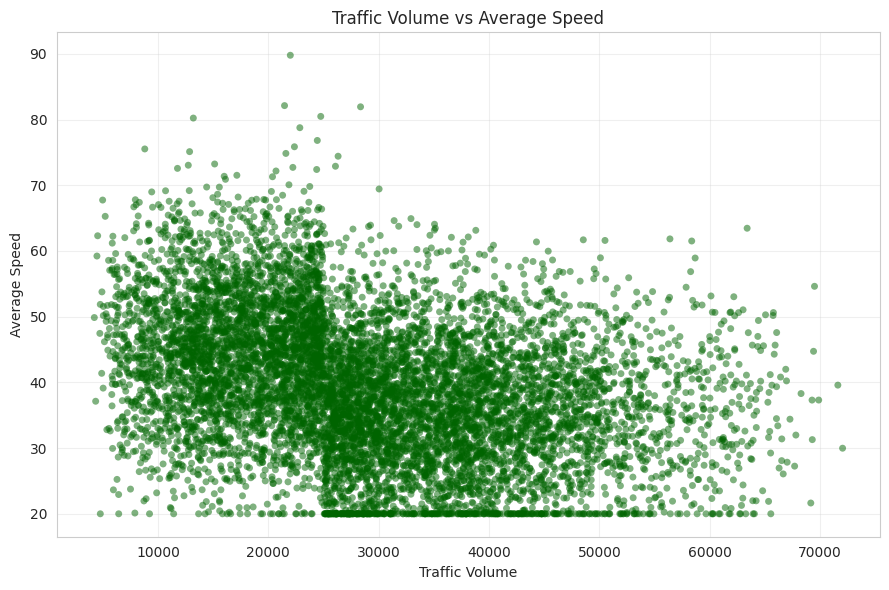

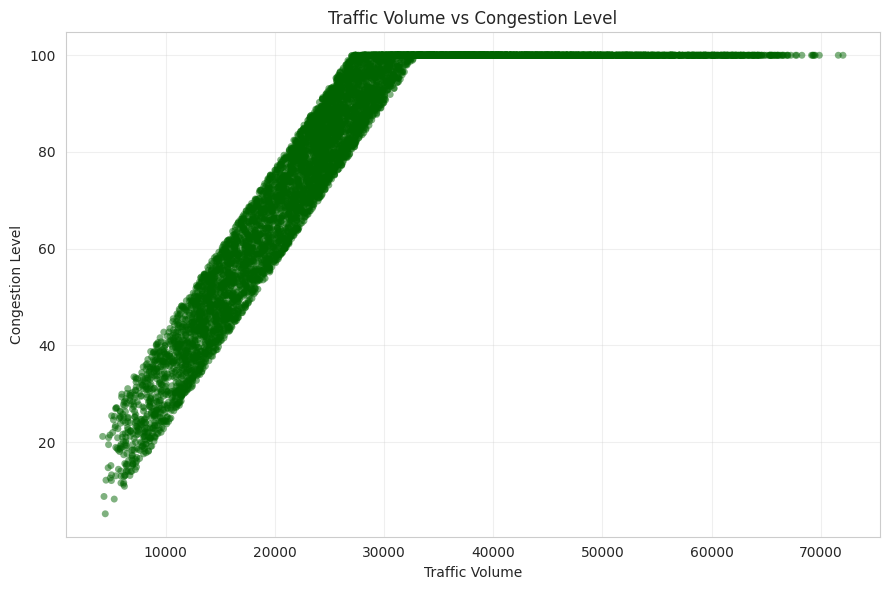

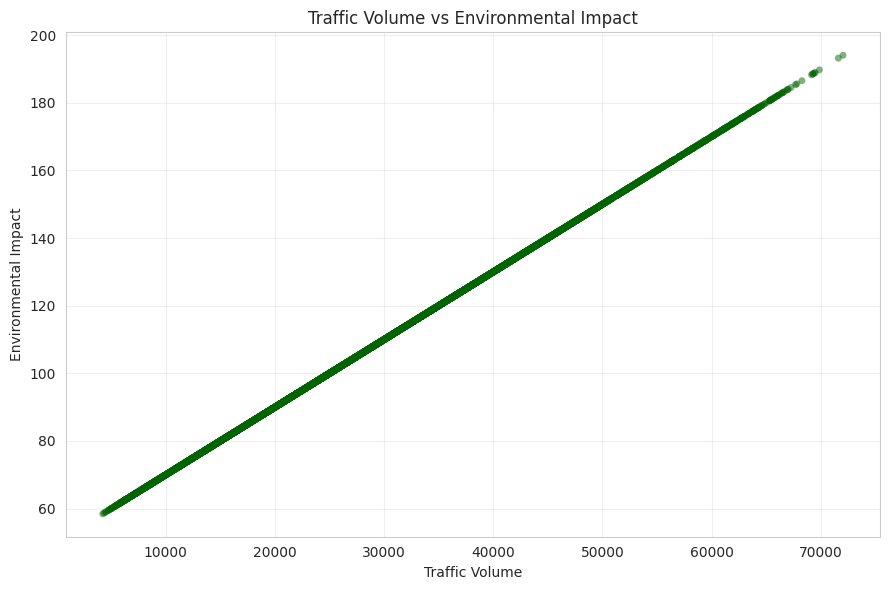

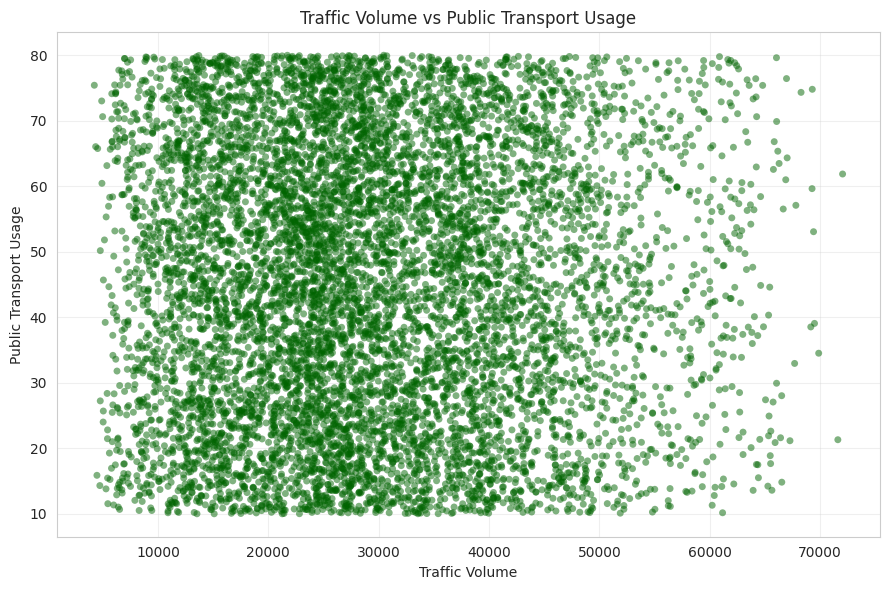

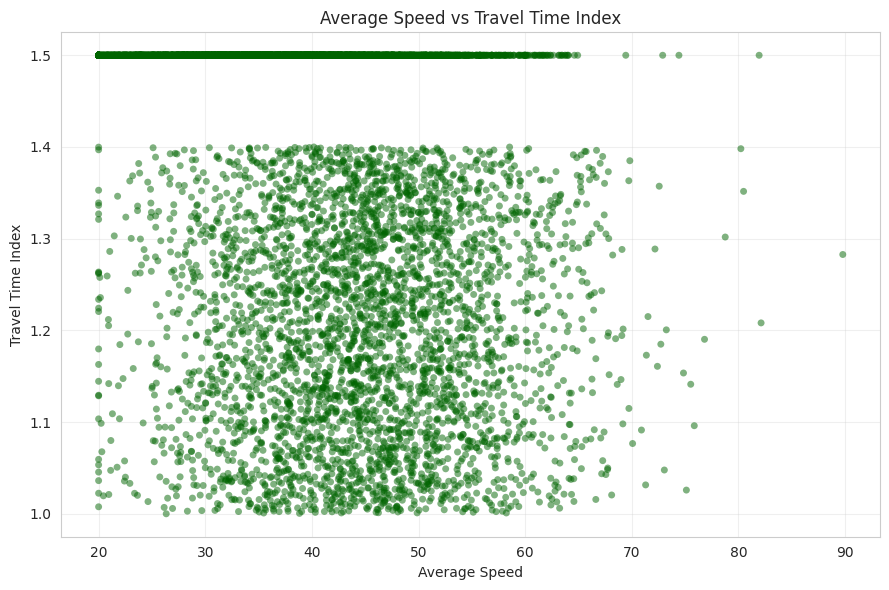

In [99]:
# I am importing the required libraries for data visualization.
import matplotlib.pyplot as plt
import seaborn as sns

# I am setting the visual style for the scatter plots.
sns.set_style("whitegrid")

# I am creating a scatter plot to examine the relationship between Traffic Volume and Average Speed.
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Traffic Volume',
    y='Average Speed',
    color='darkgreen',
    alpha=0.5,
    s=25,
    edgecolor='none'
)

plt.title('Traffic Volume vs Average Speed')
plt.xlabel('Traffic Volume')
plt.ylabel('Average Speed')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


# I am creating a scatter plot to examine the relationship between Traffic Volume and Congestion Level.
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Traffic Volume',
    y='Congestion Level',
    color='darkgreen',
    alpha=0.5,
    s=25,
    edgecolor='none'
)

plt.title('Traffic Volume vs Congestion Level')
plt.xlabel('Traffic Volume')
plt.ylabel('Congestion Level')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


# I am creating a scatter plot to examine the relationship between Traffic Volume and Environmental Impact.
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Traffic Volume',
    y='Environmental Impact',
    color='darkgreen',
    alpha=0.5,
    s=25,
    edgecolor='none'
)

plt.title('Traffic Volume vs Environmental Impact')
plt.xlabel('Traffic Volume')
plt.ylabel('Environmental Impact')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


# I am creating a scatter plot to examine the relationship between Traffic Volume and Public Transport Usage.
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Traffic Volume',
    y='Public Transport Usage',
    color='darkgreen',
    alpha=0.5,
    s=25,
    edgecolor='none'
)

plt.title('Traffic Volume vs Public Transport Usage')
plt.xlabel('Traffic Volume')
plt.ylabel('Public Transport Usage')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


# I am creating a scatter plot to examine the relationship between Average Speed and Travel Time Index.
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=df,
    x='Average Speed',
    y='Travel Time Index',
    color='darkgreen',
    alpha=0.5,
    s=25,
    edgecolor='none'
)

plt.title('Average Speed vs Travel Time Index')
plt.xlabel('Average Speed')
plt.ylabel('Travel Time Index')
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

# I. Time-based Analysis


Monthly Traffic Volume

Monthly Congestion

Weekend vs Weekday Traffic

Day-wise Average Speed

Month
January      28830.116122
February     29147.926860
March        29515.959368
April        29573.885327
May          28926.727166
June         29741.802145
July         28875.460157
August       29504.121739
September    29083.165171
October      29380.753333
November     29302.754325
December     28952.187273
Name: Traffic Volume, dtype: float64


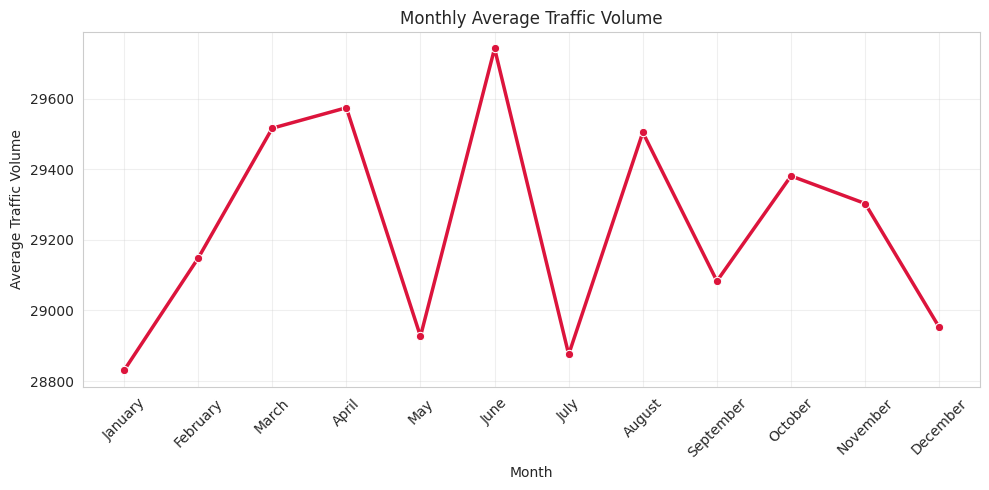

In [100]:
# I am calculating the average traffic volume for each month.
monthly_traffic = df.groupby('Month')['Traffic Volume'].mean().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

# I am displaying the average traffic volume for each month.
print(monthly_traffic)

# I am creating a line plot to visualize the monthly trend of traffic volume.
plt.figure(figsize=(10, 5))
sns.lineplot(
    x=monthly_traffic.index,
    y=monthly_traffic.values,
    marker='o',
    linewidth=2.5,
    color='crimson'
)

plt.title('Monthly Average Traffic Volume')
plt.xlabel('Month')
plt.ylabel('Average Traffic Volume')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Month
January      79.526147
February     80.751385
March        81.373568
April        81.273778
May          80.303649
June         81.116005
July         80.483730
August       81.560793
September    80.437626
October      81.448178
November     81.728129
December     80.126066
Name: Congestion Level, dtype: float64


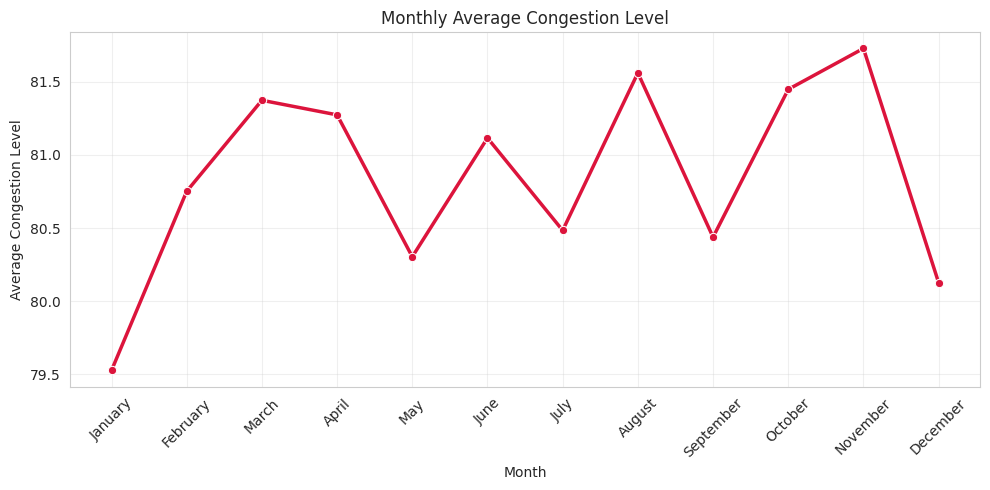

In [101]:
# I am calculating the average congestion level for each month.
monthly_congestion = df.groupby('Month')['Congestion Level'].mean().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])

# I am displaying the average congestion level for each month.
print(monthly_congestion)

# I am creating a line plot to visualize the monthly trend of congestion level.
plt.figure(figsize=(10, 5))
sns.lineplot(
    x=monthly_congestion.index,
    y=monthly_congestion.values,
    marker='o',
    linewidth=2.5,
    color='crimson'
)

plt.title('Monthly Average Congestion Level')
plt.xlabel('Month')
plt.ylabel('Average Congestion Level')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

Weekend
False    29297.170380
True     29083.982045
Name: Traffic Volume, dtype: float64


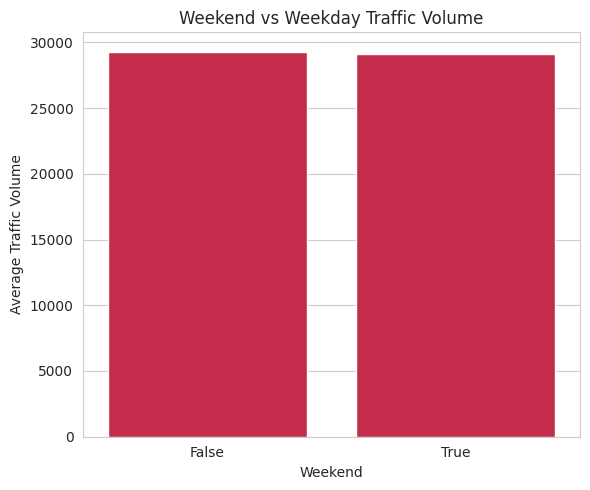

In [102]:
# I am calculating the average traffic volume for weekdays and weekends.
weekend_traffic = df.groupby('Weekend')['Traffic Volume'].mean()

# I am displaying the average traffic volume for weekdays and weekends.
print(weekend_traffic)

# I am creating a bar plot to compare the average traffic volume between weekdays and weekends.
plt.figure(figsize=(6, 5))
sns.barplot(
    x=weekend_traffic.index.astype(str),
    y=weekend_traffic.values,
    color='crimson'
)

plt.title('Weekend vs Weekday Traffic Volume')
plt.xlabel('Weekend')
plt.ylabel('Average Traffic Volume')

plt.tight_layout()

plt.show()

Day
Monday       39.237495
Tuesday      39.548279
Wednesday    39.411054
Thursday     39.469187
Friday       39.496244
Saturday     39.587561
Sunday       39.382148
Name: Average Speed, dtype: float64


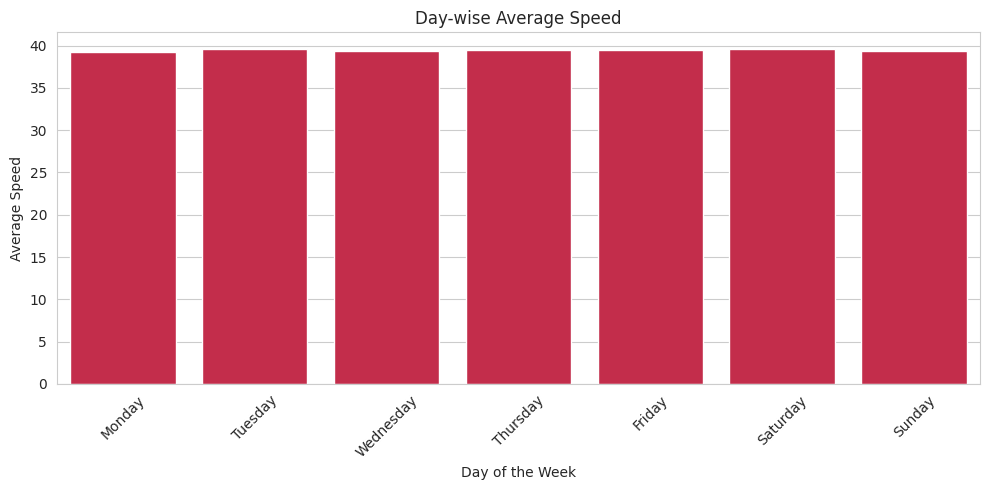

In [103]:
# I am arranging the days of the week in chronological order.
day_order = [
    'Monday', 'Tuesday', 'Wednesday', 'Thursday',
    'Friday', 'Saturday', 'Sunday'
]

# I am calculating the average speed for each day of the week.
daywise_speed = df.groupby('Day')['Average Speed'].mean().reindex(day_order)

# I am displaying the average speed for each day of the week.
print(daywise_speed)

# I am creating a bar plot to compare the average speed across different days of the week.
plt.figure(figsize=(10, 5))
sns.barplot(
    x=daywise_speed.index,
    y=daywise_speed.values,
    color='crimson'
)

plt.title('Day-wise Average Speed')
plt.xlabel('Day of the Week')
plt.ylabel('Average Speed')
plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# **6. Statistical Insights**

In [104]:
# I am displaying the summary statistics for all numerical variables.
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,8936,2023-04-22 05:25:11.548791552,2022-01-01 00:00:00,2022-08-26 00:00:00,2023-04-24 00:00:00,2023-12-17 06:00:00,2024-08-09 00:00:00,NaN
Traffic Volume,8936.0,29236.04812,4233.0,19413.0,27600.0,38058.5,72039.0,13001.808801
Average Speed,8936.0,39.447427,20.0,31.775825,39.199368,46.644517,89.790843,10.707244
Travel Time Index,8936.0,1.375554,1.000039,1.242459,1.5,1.5,1.5,0.165319
Congestion Level,8936.0,80.818041,5.160279,64.292905,92.389018,100.0,100.0,23.533182
Road Capacity Utilization,8936.0,92.029215,18.739771,97.35499,100.0,100.0,100.0,16.583341
Incident Reports,8936.0,1.570389,0.0,0.0,1.0,2.0,10.0,1.420047
Environmental Impact,8936.0,108.472096,58.466,88.826,105.2,126.117,194.078,26.003618
Public Transport Usage,8936.0,45.086651,10.006853,27.341191,45.170684,62.426485,79.979744,20.20846
Traffic Signal Compliance,8936.0,79.950243,60.003933,69.82827,79.992773,89.957358,99.993652,11.585006


In [106]:
# I am calculating the skewness of all numerical variables.
print(df.skew(numeric_only=True).sort_values(ascending=False))

Pedestrian and Cyclist Count    1.827195
Weekend                         0.943475
Incident Reports                0.914898
Environmental Impact            0.459535
Traffic Volume                  0.459535
Year                            0.261092
Average Speed                   0.243226
Traffic Signal Compliance      -0.001774
Public Transport Usage         -0.009865
Parking Usage                  -0.021749
Travel Time Index              -0.888512
Congestion Level               -0.997952
Road Capacity Utilization      -2.144140
dtype: float64


In [107]:
# I am displaying the average traffic metrics for each area.
area_summary = df.groupby('Area Name')[
    ['Traffic Volume', 'Congestion Level', 'Average Speed']
].mean().sort_values(by='Traffic Volume', ascending=False)

print(area_summary)

                 Traffic Volume  Congestion Level  Average Speed
Area Name                                                       
Koramangala        40832.253666         93.985536      36.062629
M.G. Road          35300.426382         90.579670      37.535189
Indiranagar        32284.388372         87.641890      38.644341
Hebbal             26533.232632         80.087244      40.149855
Jayanagar          24601.329923         76.998324      39.789692
Whitefield         21295.127389         69.054661      42.140866
Yeshwanthpur       18931.546322         62.369634      43.447576
Electronic City    16346.644928         54.454507      43.661789


In [108]:
# I am displaying the average traffic metrics for each road/intersection.
road_summary = df.groupby('Road/Intersection Name')[
    ['Traffic Volume', 'Congestion Level']
].mean().sort_values(by='Traffic Volume', ascending=False)

print(road_summary)

                        Traffic Volume  Congestion Level
Road/Intersection Name                                  
Sony World Junction       41470.801170         94.125087
Sarjapur Road             40189.950000         93.845163
Trinity Circle            35350.137466         90.372556
Anil Kumble Circle        35251.828722         90.782145
CMH Road                  32611.924419         88.176365
100 Feet Road             31956.852326         87.107415
Hebbal Flyover            26794.924051         80.662354
Ballari Road              26272.640756         79.514551
South End Circle          24704.119730         77.277398
Jayanagar 4th Block       24496.236207         76.712995
ITPL Main Road            21866.037778         71.101106
Marathahalli Bridge       20772.953252         67.182913
Yeshwanthpur Circle       19277.115282         63.744162
Tumkur Road               18574.490305         60.949415
Hosur Road                16557.223827         55.203745
Silk Board Junction       16134

In [109]:
# I am identifying the highest average traffic volume.
print("Area with Highest Average Traffic Volume:")
print(df.groupby('Area Name')['Traffic Volume'].mean().idxmax())

print("\nRoad with Highest Average Traffic Volume:")
print(df.groupby('Road/Intersection Name')['Traffic Volume'].mean().idxmax())

print("\nWeather Condition with Highest Average Congestion:")
print(df.groupby('Weather Conditions')['Congestion Level'].mean().idxmax())

print("\nMonth with Highest Average Traffic Volume:")
print(df.groupby(df['Date'].dt.month_name())['Traffic Volume'].mean().idxmax())

Area with Highest Average Traffic Volume:
Koramangala

Road with Highest Average Traffic Volume:
Sony World Junction

Weather Condition with Highest Average Congestion:
Windy

Month with Highest Average Traffic Volume:
June
